# Python Equity Research Dashboard

In [92]:
!pip install yfinance

## Import Libraries

In [93]:
import yfinance as yf

## 2. Download Historical Stock Data

In [94]:
company_ticker= "JPM"

In [95]:
company_ticker


'JPM'

## 2. Download Historical Stock Data

In [96]:
stock_data = yf.download(
    company_ticker,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=True
)

[*********************100%***********************]  1 of 1 completed


## 3. Explore the Dataset

In [97]:
stock_data.head()

Price,Close,High,Low,Open,Volume
Ticker,JPM,JPM,JPM,JPM,JPM
Date,,,,,
2021-01-04,109.000519,110.723811,108.056601,110.412059,16819900
2021-01-05,109.593643,110.160583,107.953877,109.017979,13731200
2021-01-06,114.739700,115.803802,111.538671,113.283105,24909100
2021-01-07,118.507660,120.531202,117.679060,118.350668,21940400
2021-01-08,118.638512,118.926344,116.981298,118.594898,12035100


## 3. Explore the Dataset

In [98]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-04 to 2025-12-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, JPM)   1255 non-null   float64
 1   (High, JPM)    1255 non-null   float64
 2   (Low, JPM)     1255 non-null   float64
 3   (Open, JPM)    1255 non-null   float64
 4   (Volume, JPM)  1255 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.8 KB


## 3. Explore the Dataset

In [99]:
stock_data.shape

(1255, 5)

## 3. Explore the Dataset

In [100]:
stock_data.columns

MultiIndex([( 'Close', 'JPM'),
            (  'High', 'JPM'),
            (   'Low', 'JPM'),
            (  'Open', 'JPM'),
            ('Volume', 'JPM')],
           names=['Price', 'Ticker'])

## 4. Calculate Daily Returns

In [101]:
stock_data["Daily Return"]=stock_data["Close"][company_ticker].pct_change()

In [102]:
stock_data.head()

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,JPM,JPM,JPM,JPM,JPM,
Date,,,,,,
2021-01-04,109.000519,110.723811,108.056601,110.412059,16819900,NaN
2021-01-05,109.593643,110.160583,107.953877,109.017979,13731200,0.005441
2021-01-06,114.739700,115.803802,111.538671,113.283105,24909100,0.046956
2021-01-07,118.507660,120.531202,117.679060,118.350668,21940400,0.032839
2021-01-08,118.638512,118.926344,116.981298,118.594898,12035100,0.001104


In [103]:
import matplotlib.pyplot as plt


## 5. Visualise the Stock Price

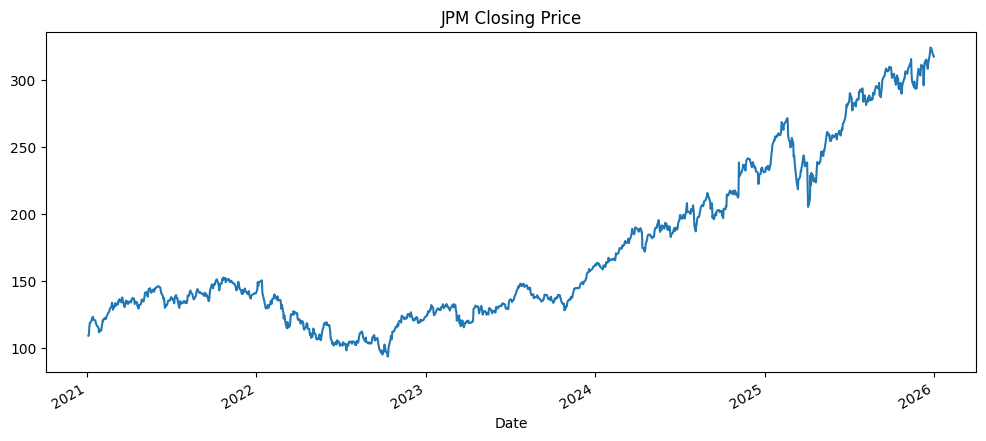

In [130]:
stock_data["Close"][company_ticker].plot(figsize=(12,5))
plt.title(f"{company_ticker} Closing Price")
plt.show()

In [105]:
stock_data["MA50"] = stock_data["Close"][company_ticker].rolling(50).mean()

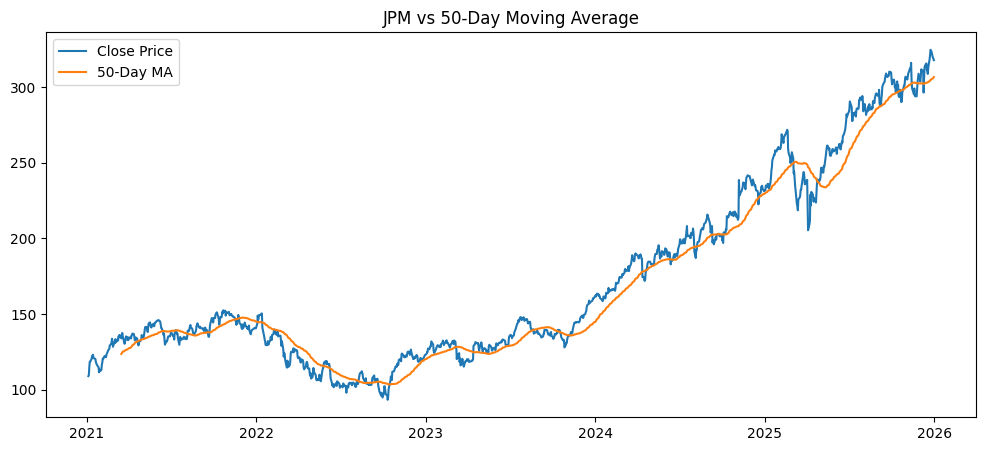

In [131]:
plt.figure(figsize=(12,5))
plt.plot(stock_data["Close"][company_ticker], label="Close Price")
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.legend()
plt.title(f"{company_ticker} vs 50-Day Moving Average")
plt.show()

In [107]:
stock_data["MA200"] = stock_data["Close"][company_ticker].rolling(200).mean()

## 6. Moving Average Analysis

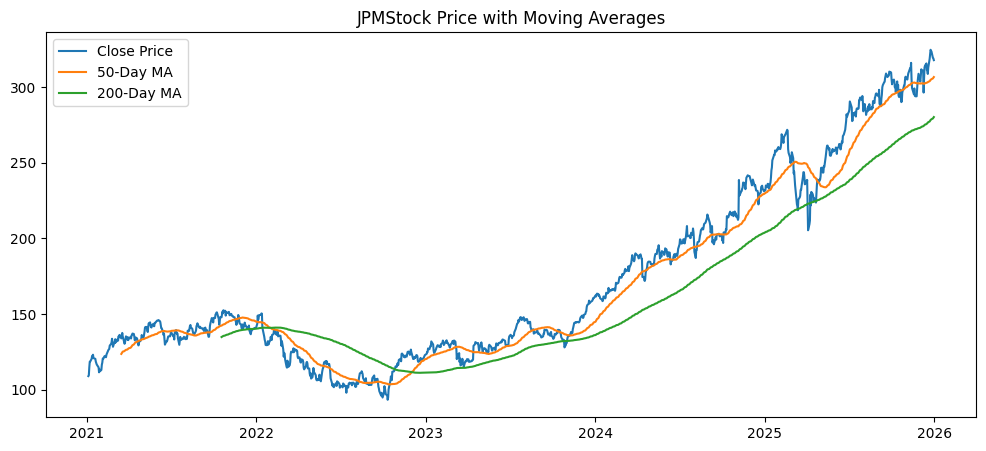

In [132]:
plt.figure(figsize=(12,5))

plt.plot(stock_data["Close"][company_ticker], label="Close Price")
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.plot(stock_data["MA200"], label="200-Day MA")

plt.title(f"{company_ticker}Stock Price with Moving Averages")
plt.legend()

plt.show()

In [109]:
stock_data["Volatility"] = stock_data["Daily Return"].rolling(30).std()

## 7. Volatility Analysis

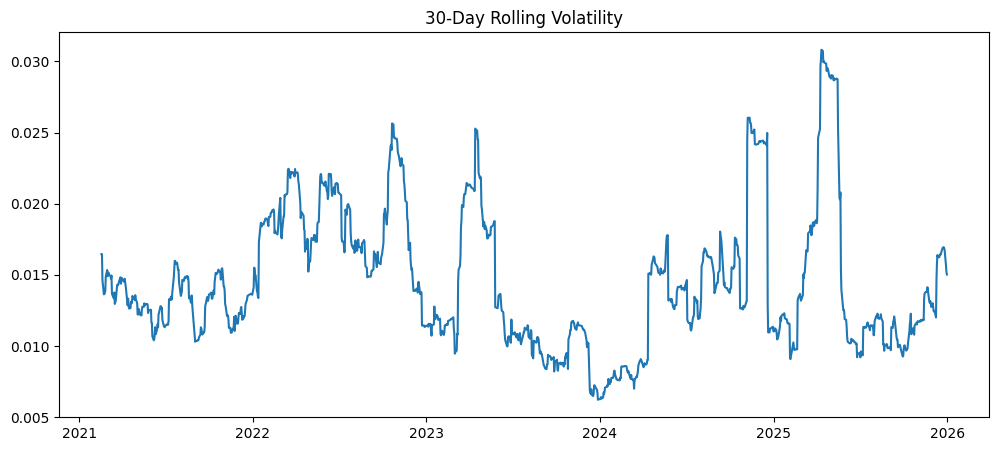

In [110]:
plt.figure(figsize=(12,5))

plt.plot(stock_data["Volatility"])

plt.title("30-Day Rolling Volatility")
plt.show()

## 8. Investment Performance

In [111]:
stock_data["Cumulative Return"] = (1 + stock_data["Daily Return"]).cumprod()

## 8. Investment Performance

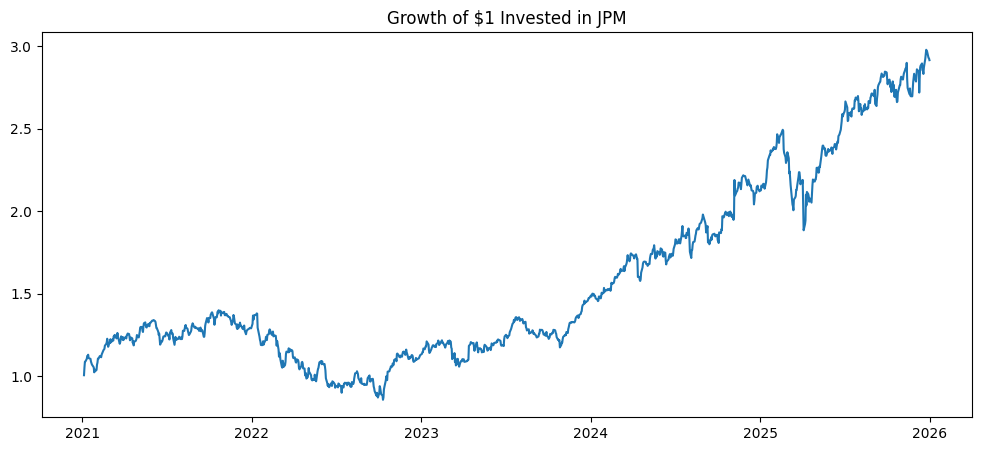

In [134]:
plt.figure(figsize=(12,5))

plt.plot(stock_data["Cumulative Return"])

plt.title(f"Growth of $1 Invested in {company_ticker}")

plt.show()

## 9. Trading Signal Strategy

In [113]:
stock_data["Signal"] = 0

In [114]:
stock_data.loc[stock_data["MA50"] > stock_data["MA200"], "Signal"] = 1

## 9. Trading Signal Strategy

In [115]:
stock_data["Position"] = stock_data["Signal"].diff()

## 9. Trading Signal Strategy

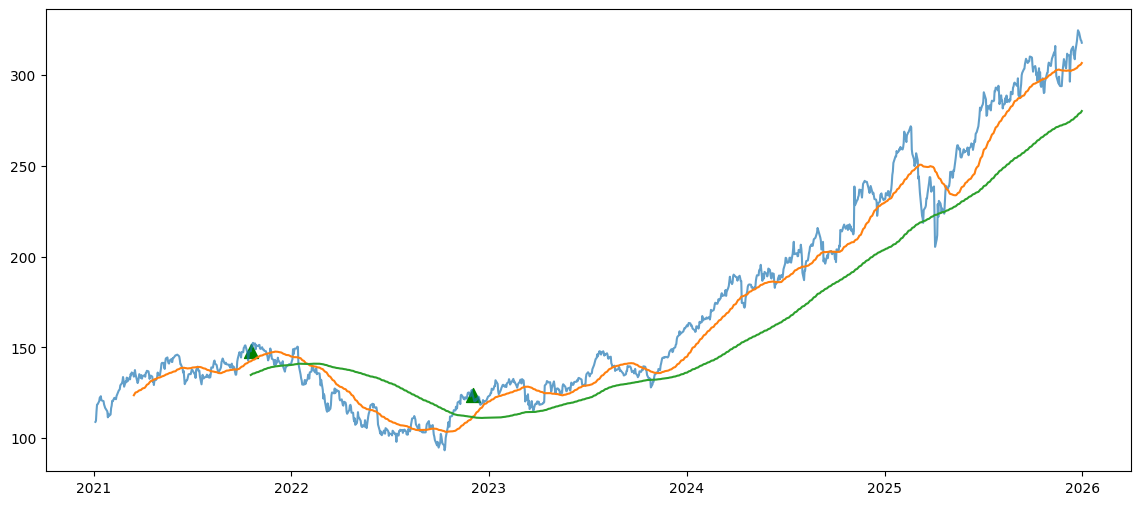

In [116]:
plt.figure(figsize=(14,6))

plt.plot(stock_data["Close"][company_ticker], label="Close Price", alpha=0.7)
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.plot(stock_data["MA200"], label="200-Day MA")
plt.scatter(
    stock_data.index[stock_data["Position"] == 1],
    stock_data["Close"][company_ticker][stock_data["Position"] == 1],
    marker="^",
    color="green",
    s=100,
    label="Buy"
)

## 9. Trading Signal Strategy

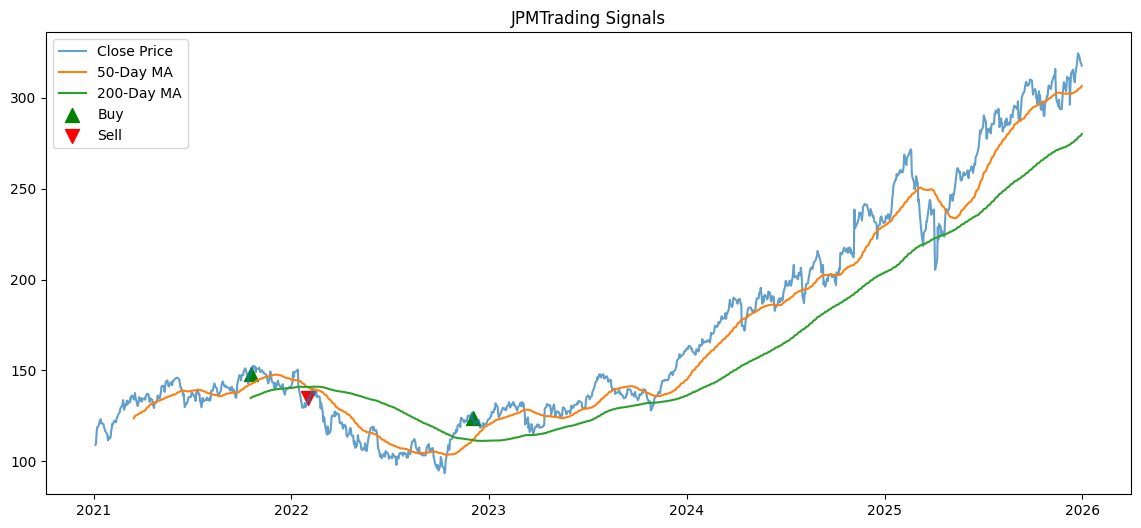

In [135]:
plt.figure(figsize=(14,6))

# Stock Price
plt.plot(stock_data["Close"][company_ticker], label="Close Price", alpha=0.7)

# Moving Averages
plt.plot(stock_data["MA50"], label="50-Day MA")
plt.plot(stock_data["MA200"], label="200-Day MA")

# Buy Signals
plt.scatter(
    stock_data.index[stock_data["Position"] == 1],
    stock_data["Close"][company_ticker][stock_data["Position"] == 1],
    marker="^",
    color="green",
    s=100,
    label="Buy"
)

# Sell Signals
plt.scatter(
    stock_data.index[stock_data["Position"] == -1],
    stock_data["Close"][company_ticker][stock_data["Position"] == -1],
    marker="v",
    color="red",
    s=100,
    label="Sell"
)

plt.title(f"{company_ticker}Trading Signals")
plt.legend()
plt.show()

In [118]:
 annual_return = stock_data["Daily Return"].mean() * 252

annual_volatility = stock_data["Daily Return"].std() * (252 ** 0.5)

sharpe_ratio = annual_return / annual_volatility

## 10. Performance Metrics

In [119]:
print("Annual Return:", annual_return)
print("Annual Volatility:", annual_volatility)
print("Sharpe Ratio:", sharpe_ratio)

Annual Return: 0.24446997295217612
Annual Volatility: 0.24274658194821386
Sharpe Ratio: 1.0070995479735732


In [120]:
latest_price = stock_data["Close"][company_ticker].iloc[-1]

In [121]:
if stock_data["MA50"].iloc[-1] > stock_data["MA200"].iloc[-1]:
    trend = "Bullish"
else:
    trend = "Bearish"

In [122]:
print("----- JPM Summary -----")
print("Latest Price: $", round(latest_price, 2))
print("Annual Return:", round(annual_return * 100, 2), "%")
print("Annual Volatility:", round(annual_volatility * 100, 2), "%")
print("Sharpe Ratio:", round(sharpe_ratio, 2))
print("Current Trend:", trend)

----- JPM Summary -----
Latest Price: $ 317.71
Annual Return: 24.45 %
Annual Volatility: 24.27 %
Sharpe Ratio: 1.01
Current Trend: Bullish


## 11. Benchmark Comparison with the S&P 500

In [123]:
sp500 = yf.download("^GSPC", start="2021-01-01", end="2025-12-31")

/tmp/ipykernel_728/2984967778.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="2021-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [124]:
sp500["Daily Return"] = sp500["Close"].pct_change()

In [125]:
sp500["Cumulative Return"] = (1 + sp500["Daily Return"]).cumprod()

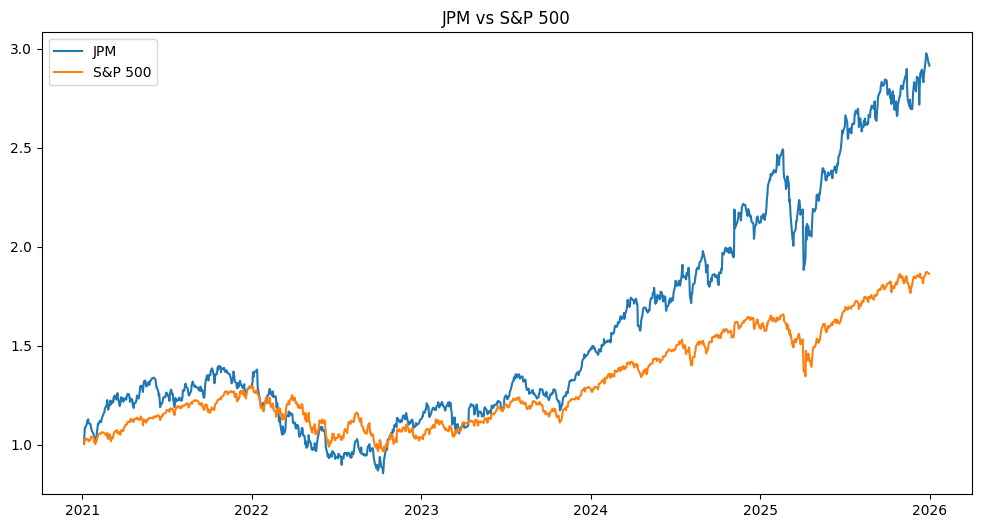

In [136]:
plt.figure(figsize=(12,6))

plt.plot(stock_data["Cumulative Return"], label="JPM")
plt.plot(sp500["Cumulative Return"], label="S&P 500")

plt.title(f"{company_ticker} vs S&P 500")
plt.legend()

plt.show()

In [127]:
import pandas as pd

## 12. Summary Dashboard

In [128]:
summary = {
    "Metric": [
        "Latest Price",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Current Trend"
    ],
    "Value": [
        round(stock_data["Close"][company_ticker].iloc[-1], 2),
        f"{annual_return:.2%}",
        f"{annual_volatility:.2%}",
        round(sharpe_ratio, 2),
        "Bullish" if stock_data["Position"].iloc[-1] == 1 else "Bearish"
    ]
}

summary_df = pd.DataFrame(summary)

summary_df

,Metric,Value
0,Latest Price,317.71
1,Annual Return,24.45%
2,Annual Volatility,24.27%
3,Sharpe Ratio,1.01
4,Current Trend,Bearish


# Conclusion

This project analysed the historical performance of a publicly traded company using Python.

Key findings:

- Calculated historical returns and volatility.
- Analysed moving-average trends.
- Generated buy and sell signals.
- Compared performance against the S&P 500.
- Calculated risk-adjusted returns using the Sharpe Ratio.


# Investment Recommendation

## Recommendation: HOLD

### Reasons

- The company generated strong long-term returns.
- Performance was compared against the S&P 500.
- The Sharpe Ratio indicates reasonable risk-adjusted returns.
- Technical indicators (50-day and 200-day moving averages) were analysed to identify buy and sell signals.
- This project is intended for educational purposes and should not be considered financial advice.

# Analyst Commentary

This project analysed the historical stock performance of a publicly traded company using Python and Yahoo Finance.

## Key Findings

- Calculated daily returns and cumulative returns.
- Measured annual return, annual volatility and Sharpe Ratio.
- Analysed 50-day and 200-day moving averages to identify trend changes.
- Compared performance against the S&P 500 benchmark.
- Built a reusable dashboard by changing only the `company_ticker` variable.